In [1]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway,chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv("merged.csv")
df.drop(columns=["Unnamed: 0"],inplace=True)

<Axes: >

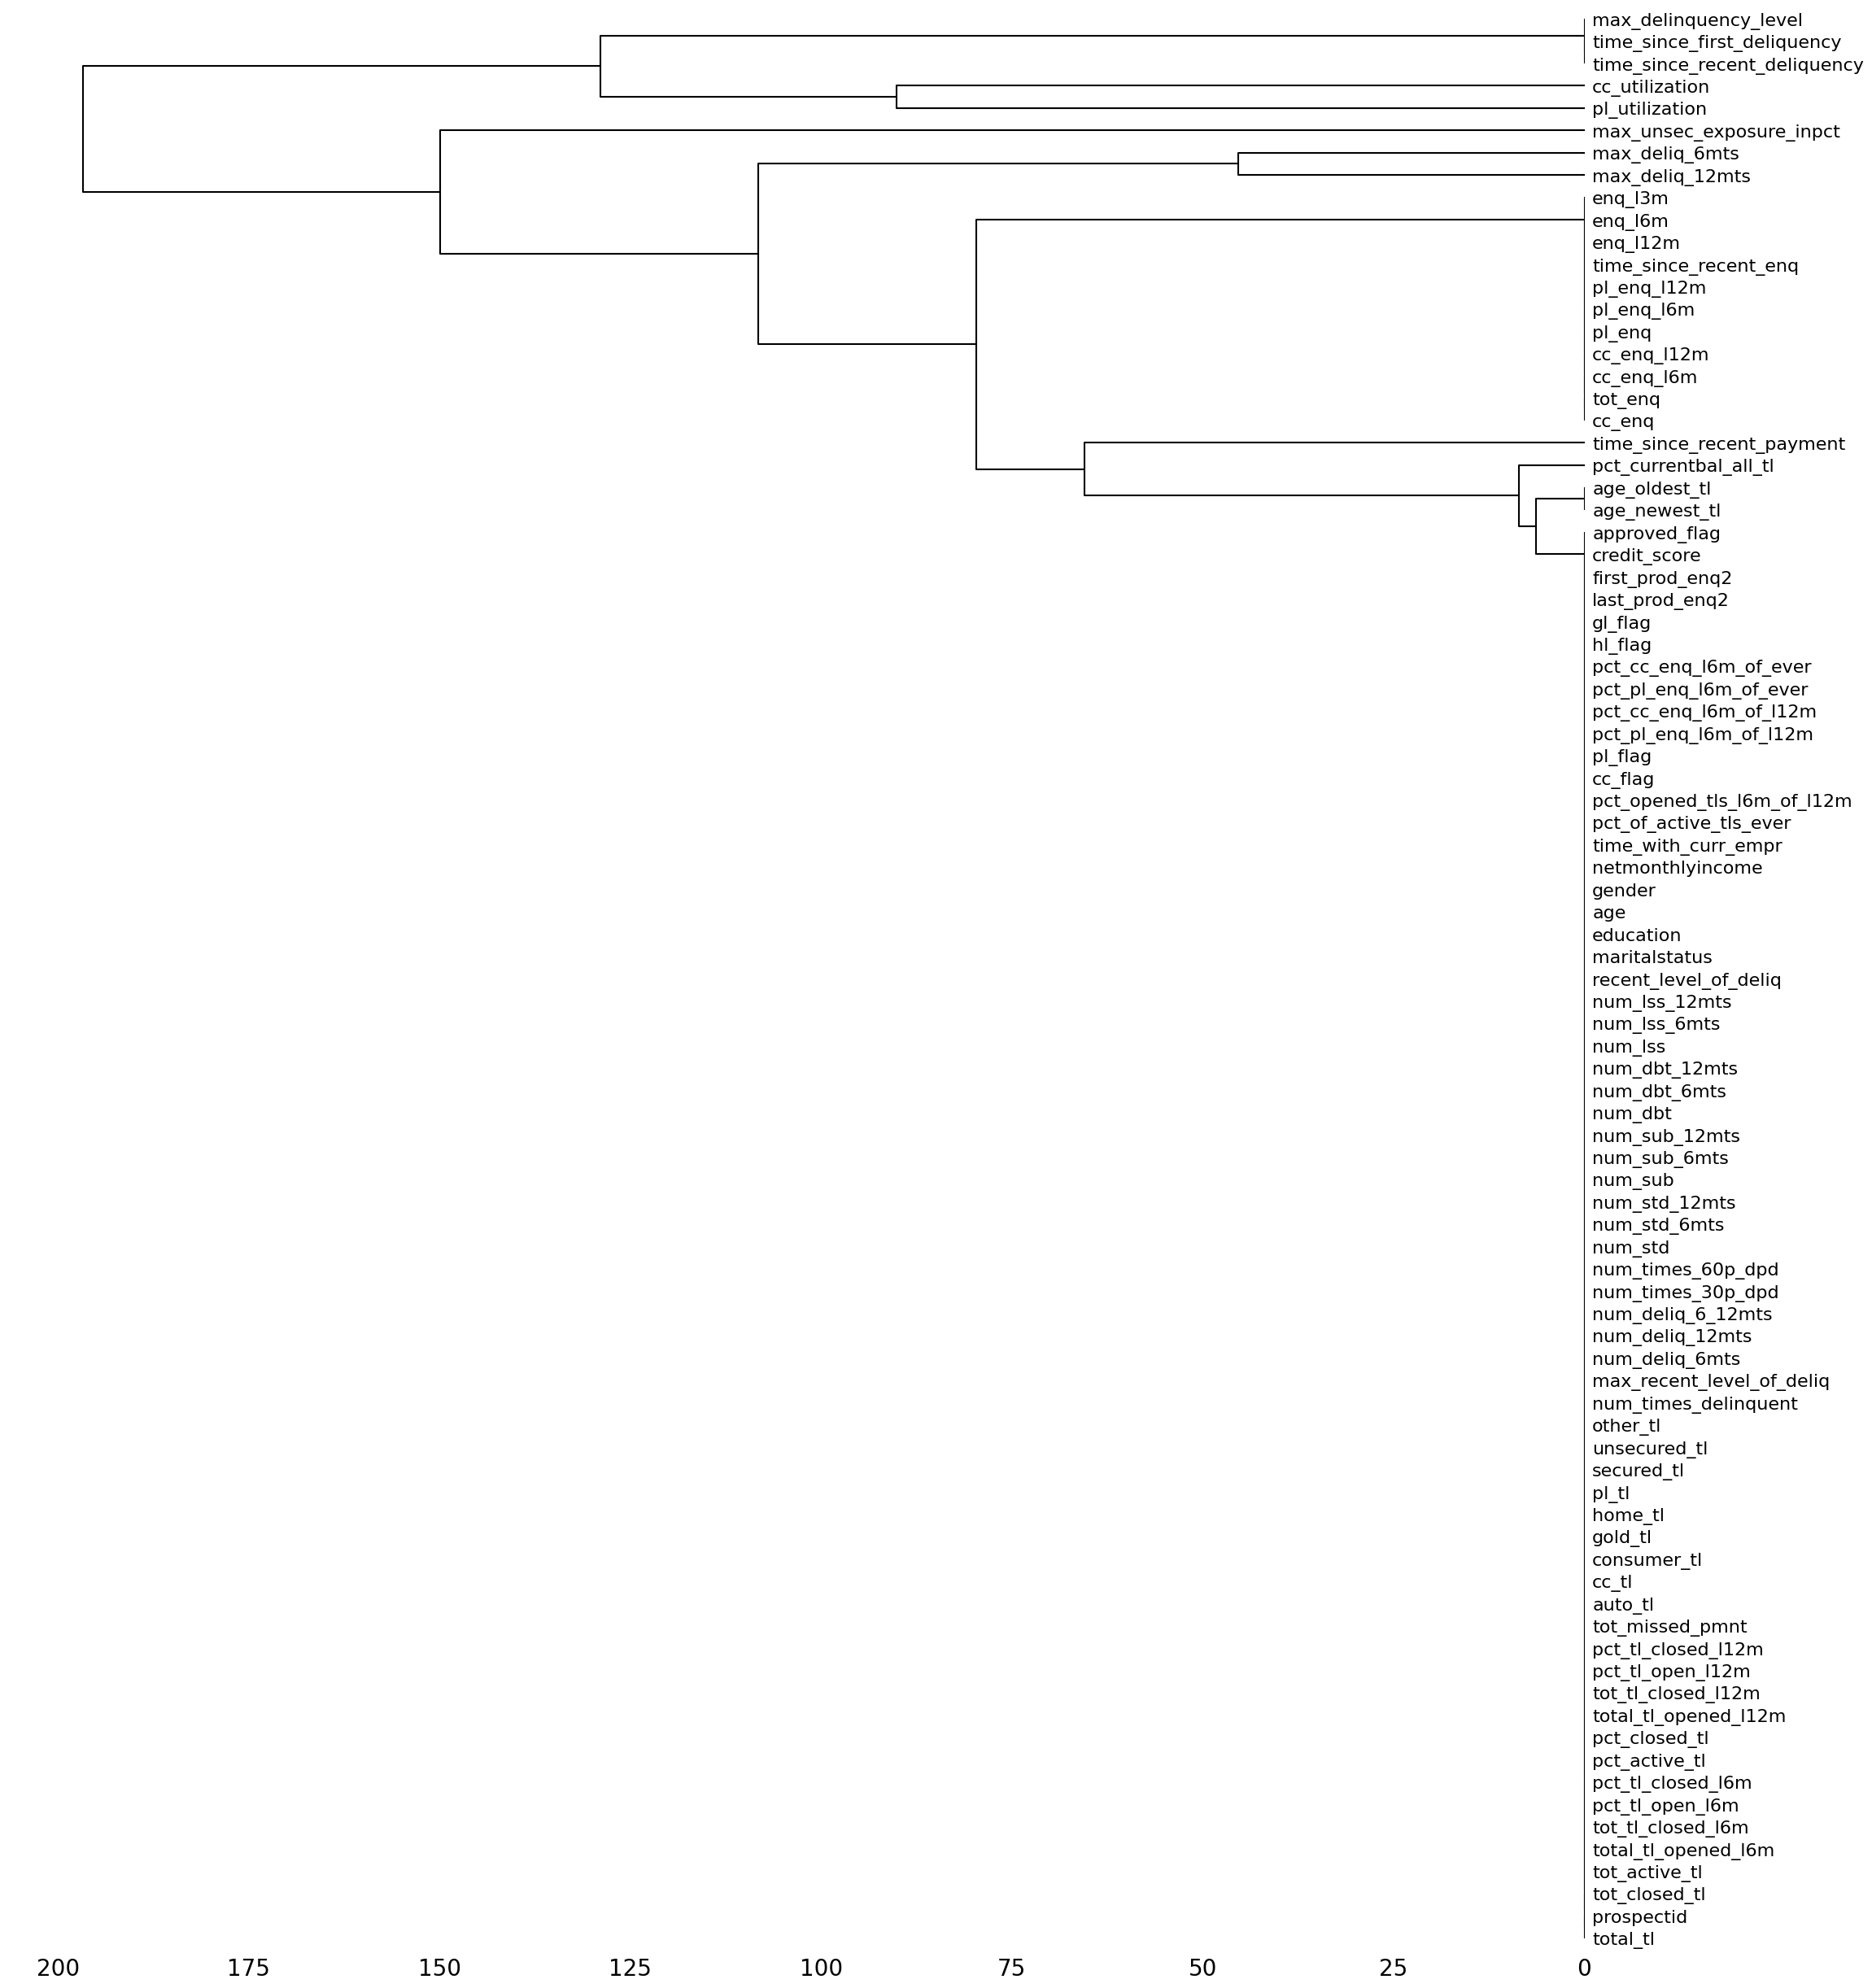

In [6]:
from missingno import dendrogram,matrix,heatmap
dendrogram(df)

<Axes: >

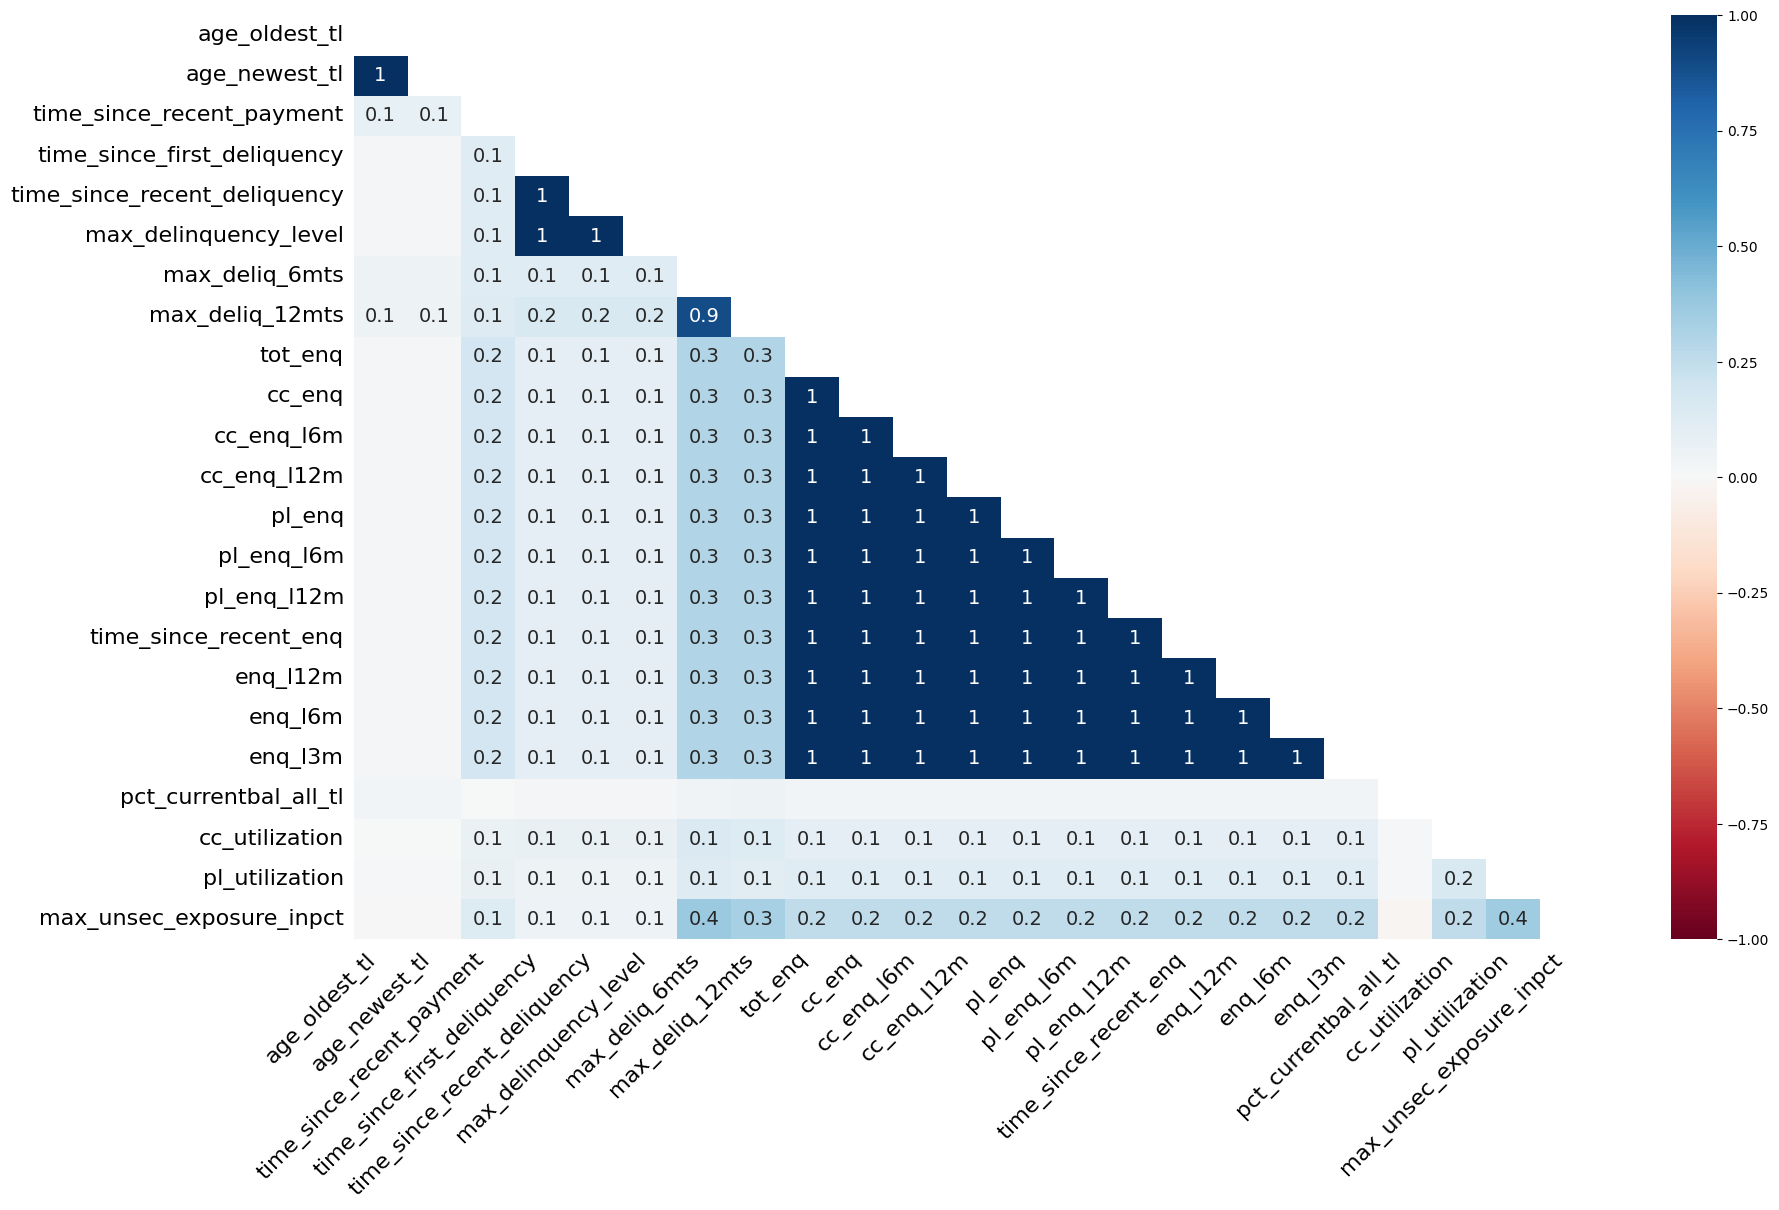

In [7]:
heatmap(df)

In [23]:
numcols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
numcols.remove("prospectid")
catcols = df.select_dtypes(include=["object","category"]).columns.tolist()
catcols.append("prospectid")

In [24]:
numdf = df[numcols]
catdf = df[catcols]

In [25]:
catdf

,maritalstatus,education,gender,last_prod_enq2,first_prod_enq2,approved_flag,prospectid
0,Married,12TH,M,PL,PL,P2,1
1,Single,GRADUATE,F,ConsumerLoan,ConsumerLoan,P2,2
2,Married,SSC,M,ConsumerLoan,others,P2,3
3,Married,SSC,M,others,others,P2,4
4,Married,POST-GRADUATE,M,AL,AL,P1,5
...,...,...,...,...,...,...,...
51331,Married,12TH,M,ConsumerLoan,ConsumerLoan,P4,51332
51332,Married,SSC,M,others,others,P1,51333
51333,Married,SSC,M,ConsumerLoan,others,P3,51334
51334,Single,UNDER GRADUATE,F,ConsumerLoan,others,P2,51335


In [6]:
numdf.head(1)

,total_tl,tot_closed_tl,tot_active_tl,total_tl_opened_l6m,tot_tl_closed_l6m,pct_tl_open_l6m,pct_tl_closed_l6m,pct_active_tl,pct_closed_tl,total_tl_opened_l12m,...,pl_utilization,pl_flag,pct_pl_enq_l6m_of_l12m,pct_cc_enq_l6m_of_l12m,pct_pl_enq_l6m_of_ever,pct_cc_enq_l6m_of_ever,max_unsec_exposure_inpct,hl_flag,gl_flag,credit_score
0,5,4,1,0,0,0.0,0.0,0.2,0.8,0,...,0.798,1,0.0,0.0,0.0,0.0,13.333,1,0,696


In [7]:
train = numdf.to_numpy()

In [8]:
knn = KNNImputer(n_neighbors=3,weights="distance")

In [9]:
new_xtrain = knn.fit_transform(train)

In [10]:
imputed_df = pd.DataFrame(new_xtrain,columns=numcols)


In [16]:
imputed_df.shape

(51336, 81)

In [14]:
imputed_df.insert(loc=0,column="prospectid",value=df["prospectid"].values)

In [26]:
model_df = imputed_df.merge(catdf,how="inner",left_on="prospectid",right_on="prospectid")

In [27]:
model_df.head(5)

,prospectid,total_tl,tot_closed_tl,tot_active_tl,total_tl_opened_l6m,tot_tl_closed_l6m,pct_tl_open_l6m,pct_tl_closed_l6m,pct_active_tl,pct_closed_tl,...,max_unsec_exposure_inpct,hl_flag,gl_flag,credit_score,maritalstatus,education,gender,last_prod_enq2,first_prod_enq2,approved_flag
0,1,5.0,4.0,1.0,0.0,0.0,0.000,0.0,0.200,0.800,...,13.333000,1.0,0.0,696.0,Married,12TH,M,PL,PL,P2
1,2,1.0,0.0,1.0,0.0,0.0,0.000,0.0,1.000,0.000,...,0.860000,0.0,0.0,685.0,Single,GRADUATE,F,ConsumerLoan,ConsumerLoan,P2
2,3,8.0,0.0,8.0,1.0,0.0,0.125,0.0,1.000,0.000,...,5741.667000,1.0,0.0,693.0,Married,SSC,M,ConsumerLoan,others,P2
3,4,1.0,0.0,1.0,1.0,0.0,1.000,0.0,1.000,0.000,...,9.900000,0.0,0.0,673.0,Married,SSC,M,others,others,P2
4,5,3.0,2.0,1.0,0.0,0.0,0.000,0.0,0.333,0.667,...,4.516263,0.0,0.0,753.0,Married,POST-GRADUATE,M,AL,AL,P1


In [28]:
model_df.to_csv("modeldf.csv",index=False)

In [29]:
model_df.isnull().sum().sum()

np.int64(0)